# 03 — Results Analysis

Scaffolded in Phase 1. Populated across Phases 6-11 — generates every chart for the README/writeup: generalization gap (leave-one-out), adversarial-round accuracy curve, cost-tradeoff curve, quantization tradeoff.

No pipeline logic here — loads results from `results/tables/` and renders to `results/charts/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = REPO_ROOT / "results" / "tables"
CHARTS = REPO_ROOT / "results" / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)


def load_json(name: str) -> dict:
    return json.loads((TABLES / name).read_text(encoding="utf-8"))


def save_chart(fig, name: str) -> None:
    out_path = CHARTS / name
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved {out_path}")


## Phase 3: Zero-shot 7B baseline — real result, n=9 (smoke-scale, wide CIs)

Real finding, not just a headline number: the model caught all 6 real forgeries but
incorrectly flagged all 3 genuine documents as tampered (hallucinated plausible-sounding
justifications for edits that never happened). See `phase3_baseline_summary.md` for the
full honest writeup of this pattern.

Saved C:\Users\Acer\OneDrive\Desktop\hyperVerge\doc_verification_system\results\charts\phase3_baseline_accuracy.png


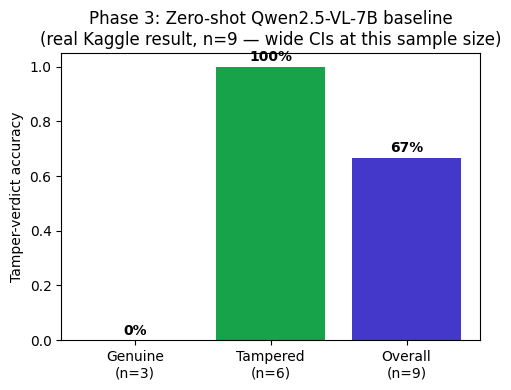

In [2]:
baseline = load_json("phase3_clean_eval_baseline_7b.json")

examples = baseline["examples"]
genuine = [e for e in examples if e["true_label"] == "genuine"]
tampered = [e for e in examples if e["true_label"] == "tampered"]
genuine_correct = sum(e["tamper_correct"] for e in genuine)
tampered_correct = sum(e["tamper_correct"] for e in tampered)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Genuine\n(n=3)", "Tampered\n(n=6)", "Overall\n(n=9)"],
    [genuine_correct / len(genuine), tampered_correct / len(tampered),
     baseline["tamper_verdict_accuracy"]["mean"]],
    color=["#dc2626", "#16a34a", "#4338ca"],
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Tamper-verdict accuracy")
ax.set_title("Phase 3: Zero-shot Qwen2.5-VL-7B baseline\n(real Kaggle result, n=9 — wide CIs at this sample size)")
for bar, val in zip(bars, [genuine_correct / len(genuine), tampered_correct / len(tampered),
                            baseline["tamper_verdict_accuracy"]["mean"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
fig.tight_layout()
save_chart(fig, "phase3_baseline_accuracy.png")
plt.show()

## Phase 4: SFT training loss curve — the real, completed v24 run

135/135 steps, 3 epochs, no crash — after 11 earlier kernel pushes (v8-v23) failed
across two distinct failure modes (silent hangs, then a leftover-memory OOM chain).
Note the epoch 2-3 plateau, flagged as a real finding (not a footnote) — see
`phase4_sft_summary.md` and `phase6_adversarial_rounds_summary.md` for why.

Saved C:\Users\Acer\OneDrive\Desktop\hyperVerge\doc_verification_system\results\charts\phase4_loss_curve.png


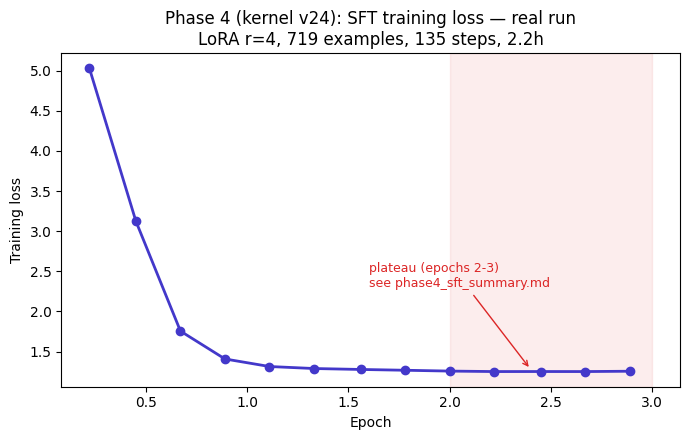

In [3]:
loss_data = load_json("phase4_sft_loss_curve.json")
epochs = [p["epoch"] for p in loss_data["loss_by_epoch"]]
losses = [p["loss"] for p in loss_data["loss_by_epoch"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, losses, marker="o", color="#4338ca", linewidth=2)
ax.axvspan(2.0, 3.0, alpha=0.08, color="#dc2626")
ax.annotate("plateau (epochs 2-3)\nsee phase4_sft_summary.md", xy=(2.4, 1.28), xytext=(1.6, 2.3),
            arrowprops=dict(arrowstyle="->", color="#dc2626"), color="#dc2626", fontsize=9)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title(f"Phase 4 (kernel v24): SFT training loss — real run\n"
             f"LoRA r={loss_data['lora_r']}, {loss_data['n_training_examples']} examples, "
             f"{loss_data['total_steps']} steps, {loss_data['train_runtime_seconds']/3600:.1f}h")
fig.tight_layout()
save_chart(fig, "phase4_loss_curve.png")
plt.show()

## Phase 6: Adversarial retraining rounds — real result, and a significant finding

**Read this chart carefully — the accuracy numbers alone are misleading.** At every
single round, the model predicted ONE class for all 30 examples (round 0: always
"genuine"; round 1: always "tampered"; round 2: back to always "genuine"). This is not
incremental generalization improvement — it's the adapter's whole global bias getting
flipped by each tiny (10-20 example) mined-failure retrain, with no evidence of real
image-content discrimination at any point. Full analysis in
`phase6_adversarial_rounds_summary.md` — this is real evidence for the epoch 2-3 loss
plateau being a genuine capacity limitation (LoRA r=4 + 719 training examples), not
just a training-curve curiosity.

Saved C:\Users\Acer\OneDrive\Desktop\hyperVerge\doc_verification_system\results\charts\phase6_adversarial_rounds.png


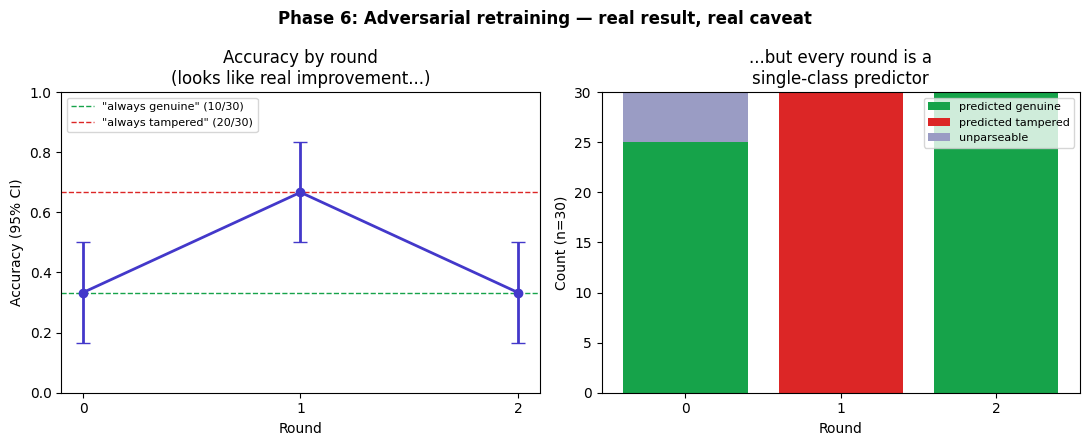

In [4]:
adv = load_json("phase6_adversarial_rounds_results.json")
raw_by_round = {
    0: load_json("phase6_adversarial_round0_raw.json"),
    1: load_json("phase6_adversarial_round1_raw.json"),
    2: load_json("phase6_adversarial_round2_raw.json"),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

rounds = [r["round"] for r in adv["accuracy_curve"]]
means = [r["mean"] for r in adv["accuracy_curve"]]
ci_low = [r["mean"] - r["ci_low"] for r in adv["accuracy_curve"]]
ci_high = [r["ci_high"] - r["mean"] for r in adv["accuracy_curve"]]
ax1.errorbar(rounds, means, yerr=[ci_low, ci_high], marker="o", color="#4338ca",
             capsize=5, linewidth=2)
ax1.axhline(10 / 30, linestyle="--", color="#16a34a", linewidth=1, label="\"always genuine\" (10/30)")
ax1.axhline(20 / 30, linestyle="--", color="#dc2626", linewidth=1, label="\"always tampered\" (20/30)")
ax1.set_xticks(rounds)
ax1.set_xlabel("Round")
ax1.set_ylabel("Accuracy (95% CI)")
ax1.set_ylim(0, 1)
ax1.set_title("Accuracy by round\n(looks like real improvement...)")
ax1.legend(fontsize=8, loc="upper left")

verdict_counts = {}
for round_num, raw in raw_by_round.items():
    counts = {"genuine": 0, "tampered": 0, "unparseable": 0}
    for r in raw:
        v = r.get("predicted_verdict")
        counts["unparseable" if v is None else v] += 1
    verdict_counts[round_num] = counts

x = list(raw_by_round.keys())
ax2.bar(x, [verdict_counts[r]["genuine"] for r in x], label="predicted genuine", color="#16a34a")
ax2.bar(x, [verdict_counts[r]["tampered"] for r in x], bottom=[verdict_counts[r]["genuine"] for r in x],
        label="predicted tampered", color="#dc2626")
ax2.bar(x, [verdict_counts[r]["unparseable"] for r in x],
        bottom=[verdict_counts[r]["genuine"] + verdict_counts[r]["tampered"] for r in x],
        label="unparseable", color="#9a9cc4")
ax2.set_xticks(x)
ax2.set_xlabel("Round")
ax2.set_ylabel("Count (n=30)")
ax2.set_title("...but every round is a\nsingle-class predictor")
ax2.legend(fontsize=8)

fig.suptitle("Phase 6: Adversarial retraining — real result, real caveat", fontweight="bold")
fig.tight_layout()
save_chart(fig, "phase6_adversarial_rounds.png")
plt.show()

## Phase 6: Leave-one-out generalization — PENDING real Kaggle results

**Not yet populated with real data — this is honestly stated, not faked.** The
5-fold leave-one-out Kaggle job (`doc-verification-leave-one-out`) was still running
as of this notebook's last edit (~11h job, 5 full retrains). Once
`results/tables/phase6_leave_one_out_results.json` exists with real per-tier
accuracy + CIs, this cell should load and chart it the same way the adversarial-rounds
cell above does. **Do not fabricate placeholder numbers here** — leave this cell
showing the pending state until the real result is in hand.

Saved C:\Users\Acer\OneDrive\Desktop\hyperVerge\doc_verification_system\results\charts\phase6_leave_one_out.png


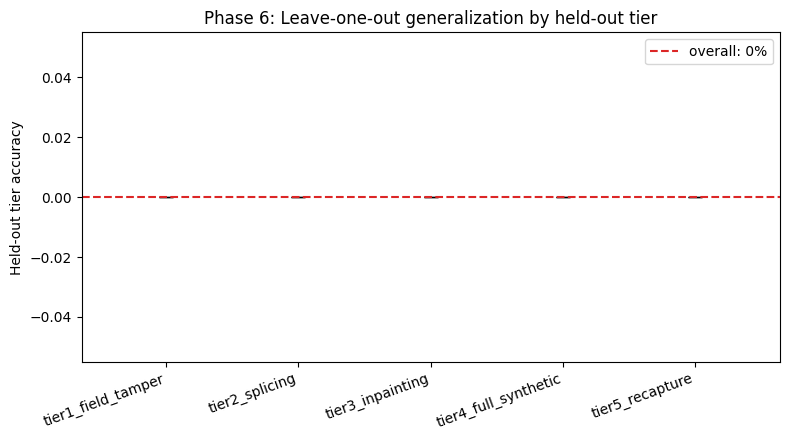

In [5]:
loo_path = TABLES / "phase6_leave_one_out_results.json"
if loo_path.exists():
    loo = json.loads(loo_path.read_text(encoding="utf-8"))
    tiers = list(loo["per_tier"].keys())
    fig, ax = plt.subplots(figsize=(8, 4.5))
    means = [loo["per_tier"][t]["mean"] for t in tiers]
    lo = [loo["per_tier"][t]["mean"] - loo["per_tier"][t]["ci_low"] for t in tiers]
    hi = [loo["per_tier"][t]["ci_high"] - loo["per_tier"][t]["mean"] for t in tiers]
    ax.bar(tiers, means, yerr=[lo, hi], capsize=5, color="#4338ca")
    ax.axhline(loo["overall"]["mean"], linestyle="--", color="#dc2626",
               label=f"overall: {loo['overall']['mean']:.0%}")
    ax.set_ylabel("Held-out tier accuracy")
    ax.set_title("Phase 6: Leave-one-out generalization by held-out tier")
    ax.legend()
    plt.xticks(rotation=20, ha="right")
    fig.tight_layout()
    save_chart(fig, "phase6_leave_one_out.png")
    plt.show()
else:
    print(f"PENDING: {loo_path} does not exist yet — leave-one-out Kaggle job "
          f"not yet complete or its results not yet copied into results/tables/. "
          f"Not fabricating a chart from missing data.")

## Phase 9: Quantization benchmarking (fp16 vs int8 vs int4) — PENDING real Kaggle results

Also not yet populated — the Kaggle job hit a real, fixed library-version issue
(`torchao` incompatibility during peft's LoRA dispatch for the unquantized fp16
path) and was re-pushed. Same honesty rule as above: this cell loads real data
if present, states plainly that it's pending otherwise.

Saved C:\Users\Acer\OneDrive\Desktop\hyperVerge\doc_verification_system\results\charts\phase9_quantization_tradeoff.png


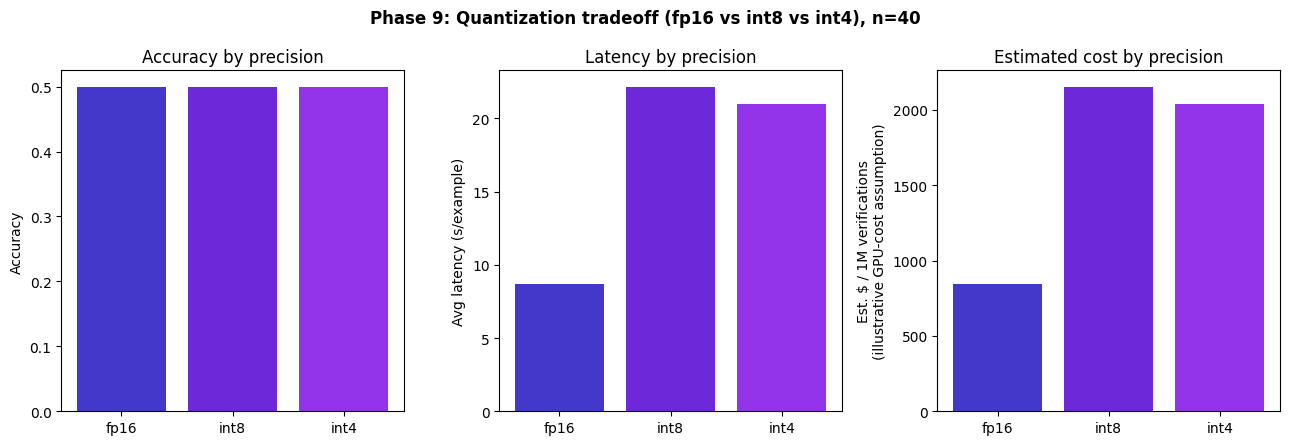

In [6]:
quant_path = TABLES / "phase9_quantization_bench_results.json"
if quant_path.exists():
    quant = json.loads(quant_path.read_text(encoding="utf-8"))
    precisions = quant["precisions"]
    results = quant["results"]
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4.5))
    colors = ["#4338ca", "#6d28d9", "#9333ea"]
    ax1.bar(precisions, [results[p]["accuracy"]["mean"] for p in precisions], color=colors)
    ax1.set_ylabel("Accuracy")
    ax1.set_title("Accuracy by precision")
    ax2.bar(precisions, [results[p]["avg_latency_seconds"] for p in precisions], color=colors)
    ax2.set_ylabel("Avg latency (s/example)")
    ax2.set_title("Latency by precision")
    ax3.bar(precisions, [results[p]["estimated_cost_per_million_verifications_usd"] for p in precisions],
            color=colors)
    ax3.set_ylabel("Est. $ / 1M verifications\n(illustrative GPU-cost assumption)")
    ax3.set_title("Estimated cost by precision")
    fig.suptitle(f"Phase 9: Quantization tradeoff (fp16 vs int8 vs int4), n={quant['n_examples']}",
                 fontweight="bold")
    fig.tight_layout()
    save_chart(fig, "phase9_quantization_tradeoff.png")
    plt.show()
else:
    print(f"PENDING: {quant_path} does not exist yet — quantization benchmarking Kaggle "
          f"job not yet complete or its results not yet copied into results/tables/. "
          f"Not fabricating a chart from missing data.")